In [1]:
# PS 1:
# Study the effect of learning rate on model convergence and stability.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# subset for CPU
x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7630 - loss: 0.8168
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9545 - loss: 0.1503
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9360 - loss: 0.1957
Accuracy: 0.9359999895095825


In [2]:
# PS 2:
# Analyse how increasing epochs influence overfitting and generalisation.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6556 - loss: 1.2022 - val_accuracy: 0.8450 - val_loss: 0.4580
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8763 - loss: 0.4187 - val_accuracy: 0.9025 - val_loss: 0.2930
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.2835 - val_accuracy: 0.9200 - val_loss: 0.2623
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9400 - loss: 0.2067 - val_accuracy: 0.9325 - val_loss: 0.2315
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9544 - loss: 0.1490 - val_accuracy: 0.9400 - val_loss: 0.2207
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9020 - loss: 0.2766
Accuracy: 0.9020000100135803


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7075 - loss: 1.1243 - val_accuracy: 0.8650 - val_loss: 0.4225
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8819 - loss: 0.4071 - val_accuracy: 0.9200 - val_loss: 0.2627
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9175 - loss: 0.2776 - val_accuracy: 0.9225 - val_loss: 0.2532
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9375 - loss: 0.2127 - val_accuracy: 0.9350 - val_loss: 0.2148
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9588 - loss: 0.1540 - val_accuracy: 0.9450 - val_loss: 0.1985


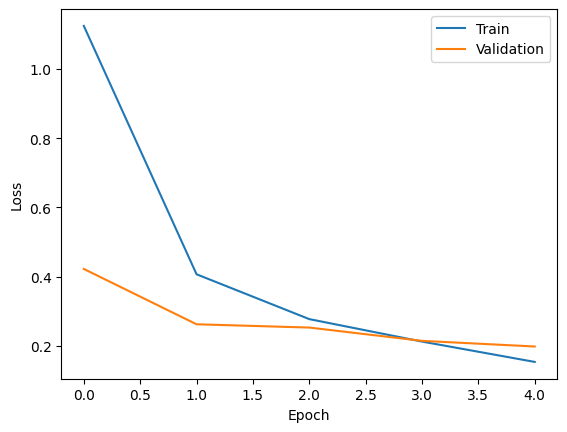

In [3]:
# PS 3:
# Plot and interpret training vs validation loss curves.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [4]:
# PS 4:
# Compare model performance under different hyperparameter settings.

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train[:2000]
y_train = y_train[:2000]

x_test = x_test[:500]
y_test = y_test[:500]

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = Sequential([
    Conv2D(64, (5,5), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=2)

loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7770 - loss: 0.7377
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9365 - loss: 0.2301
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9160 - loss: 0.2563 
Accuracy: 0.9160000085830688
